In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import pandas as pd
import backbone as bb
import pickle
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD,Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Flatten,Dense,BatchNormalization,Activation,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.preprocessing import flow_from_dataframe

In [2]:
#import train labels dataset using backbone module
file_path_trainlabels, file_path_trainimages, train_labels = bb.init_data()

train_labels['label'] = train_labels['label'].astype('str')

In [3]:
IMG_SIZE = (224,224) # this image size depends on what the model we are using requires! mobilenet wants 224x224 in any case

### Preprocessing data, generating training and validation split

In [4]:
#Data augmentation for the training set:
train_datagen = ImageDataGenerator(#rescale=1./255,
                                   validation_split=0.2,
                                    rotation_range=2, 
                                    horizontal_flip=True,
                                    zoom_range=0.1)

#Pre-processing the validation set (without data augmentation):
val_datagen = ImageDataGenerator(validation_split=0.2)

#Initiate a generator for the test set
test_datagen = ImageDataGenerator() #rescale=1./255

In [5]:
#Train dataset generator
train_generator=train_datagen.flow_from_dataframe(dataframe=train_labels, #dataframe with the image names and labels
                                            directory=file_path_trainimages, #filepath images
                                            x_col='img_name',
                                            y_col='label',
                                            subset='training',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42, #how the data is randomized
                                            shuffle=True,
                                            class_mode='categorical',
                                            class_names=None,
                                            interpolation='nearest', #interpolation for resizing images. 
                                            target_size=IMG_SIZE)
#Efficientnet uses bicubic interpolation to resize images so perhaps use that too? - No improvement

Found 24490 validated image filenames belonging to 80 classes.


In [6]:
#Validation dataset generator
val_generator=val_datagen.flow_from_dataframe(dataframe=train_labels,
                                            directory=file_path_trainimages,
                                            x_col='img_name',
                                            y_col='label',
                                            subset='validation',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42,
                                            shuffle=True,
                                            class_mode='categorical',
                                            class_names=None,
                                            interpolation='nearest',
                                            target_size=IMG_SIZE)

Found 6122 validated image filenames belonging to 80 classes.


### Generating class weights

In [7]:
#Balancing dataset by setting weights to the labels
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight('balanced', np.unique(train_generator.classes), train_generator.classes)

class_weights = {i : class_weights[i] for i in train_generator.classes}

#then use:    model.fit_generator(train_generator, class_weight=class_weights)

## Creating the base model (Efficientnet B0)

Efficientnet B0 is pre-trained on ImageNet (1.4 images, 1000 classes).

First we need to pick which layer of MobileNetv2 we will use for feature extraction. The very last classification layer (i.e. the 'top' layer) is not very useful since these features might be too specific.

Instead we will use the common practice to depend on the very last layer before the flatten operation, also called the 'bottleneck layer'. The bottleneck layer features retain more generality as compared to the final/top layer.

We instantiate an Efficientnet B0 model pre-loaded with the weights trained on Imagenet. By speficying include_top = False, we load a network that doesn't include the classification layers at the top, which is ideal for feature extraction.

In [8]:
# create base model from pre-trained mobilenet v2
IMG_SHAPE = (IMG_SIZE) + (3,)
base_model = tf.keras.applications.EfficientNetB0(input_shape = IMG_SHAPE,
                                              include_top = False,
                                              weights = 'imagenet')

In [9]:
IMG_SHAPE

(224, 224, 3)

## Feature Extraction

In [10]:
base_model.trainable = False # we prevent the weights from being updated during training

# taking a look at our base model architecture:
base_model.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
rescaling (Rescaling)           (None, 224, 224, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
normalization (Normalization)   (None, 224, 224, 3)  7           rescaling[0][0]                  
__________________________________________________________________________________________________
stem_conv_pad (ZeroPadding2D)   (None, 225, 225, 3)  0           normalization[0][0]              
_____________________________________________________________________________________

### Building the model

In [11]:
inputs = tf.keras.Input(shape=(IMG_SHAPE))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(80, activation='softmax')(x)
model = Model(inputs, outputs)

In [12]:
#create learning decay for optimizer
#lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    #initial_learning_rate=1.5e-2,
    #decay_steps=10000,
    #decay_rate=0.9)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
#Checking the final model summary
model.summary()

Model: "functional_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
efficientnetb0 (Functional)  (None, 7, 7, 1280)        4049571   
_________________________________________________________________
global_average_pooling2d (Gl (None, 1280)              0         
_________________________________________________________________
batch_normalization (BatchNo (None, 1280)              5120      
_________________________________________________________________
dropout (Dropout)            (None, 1280)              0         
_________________________________________________________________
dense (Dense)                (None, 80)                102480    
Total params: 4,157,171
Trainable params: 105,040
Non-trainable params: 4,052,131
______________________________________

### Training the model

In [14]:
history = model.fit(x=train_generator,
                    validation_data=val_generator,
                    epochs=10,
                    verbose=1,
                    class_weight=class_weights)

Epoch 1/10
766/766 [==============================] - 1235s 2s/step - loss: 2.6349 - accuracy: 0.3855 - val_loss: 1.9576 - val_accuracy: 0.5255
Epoch 2/10
766/766 [==============================] - 1208s 2s/step - loss: 1.8387 - accuracy: 0.5324 - val_loss: 1.8838 - val_accuracy: 0.5421
Epoch 3/10
766/766 [==============================] - 1233s 2s/step - loss: 1.6003 - accuracy: 0.5779 - val_loss: 1.8521 - val_accuracy: 0.5613
Epoch 4/10
766/766 [==============================] - 1214s 2s/step - loss: 1.4857 - accuracy: 0.5990 - val_loss: 1.8446 - val_accuracy: 0.5699
Epoch 5/10
766/766 [==============================] - 1220s 2s/step - loss: 1.3957 - accuracy: 0.6190 - val_loss: 1.8694 - val_accuracy: 0.5596
Epoch 6/10
766/766 [==============================] - 1227s 2s/step - loss: 1.3539 - accuracy: 0.6247 - val_loss: 1.8685 - val_accuracy: 0.5673
Epoch 7/10
766/766 [==============================] - 1229s 2s/step - loss: 1.3060 - accuracy: 0.6397 - val_loss: 1.8968 - val_accuracy:

### Saving the model

In [15]:
#save image classifier model using pickle 
#save_classifier = open("efficientnet_b0.pickle","wb")
#pickle.dump(history, save_classifier)
#save_classifier.close()

#save model using built-in function
model.save('efficientnet_b0_model2.h5')
model.save_weights('efficientnet_b0_model2_weights.h5')

### Generating the learning curves

Text(0.5, 1.0, 'Training and Validation Accuracy')

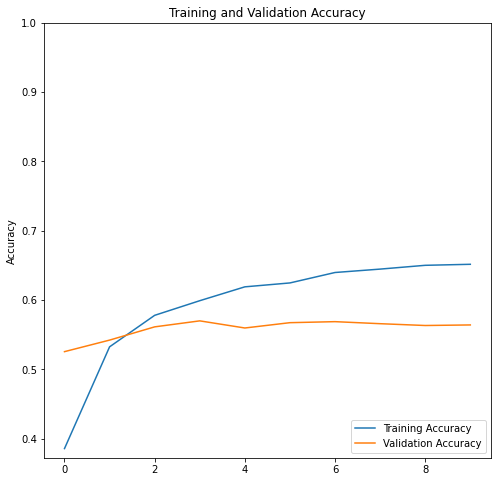

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
# plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

# plt.subplot(2, 1, 2)
# plt.plot(loss, label='Training Loss')
# plt.plot(val_loss, label='Validation Loss')
# plt.legend(loc='upper right')
# plt.ylabel('Cross Entropy')
# plt.ylim([0,1.0])
# plt.title('Training and Validation Loss')
# plt.xlabel('epoch')
# plt.show()

## Classifying the Test Dataset

In [17]:
file_path_testimages, file_path_testlabels, test_labels = bb.get_test_paths()

#Test dataset generator
test_generator=test_datagen.flow_from_dataframe(dataframe=test_labels,
                                            directory=file_path_testimages,
                                            x_col='img_name',
                                            y_col='label',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42,
                                            shuffle=False,
                                            class_mode=None,
                                            interpolation='nearest',
                                            target_size=IMG_SIZE)

Found 7653 validated image filenames.


In [ ]:
#load model if required
from tensorflow.keras.models import load_model
model = load_model('efficientnet_b0_model.h5')

In [18]:
test_generator.reset()

#classify our test data
classify = model.predict(test_generator,
                         verbose=1)

240/240 [==============================] - 306s 1s/step


In [19]:
predictions = np.argmax(classify, axis=1)
predictions

array([ 6, 56,  8, ..., 72, 41,  5], dtype=int64)

In [20]:
#map predicted labels to the labels indices
sorted_labels = (train_generator.class_indices)
sorted_labels = dict((v,k) for k,v in sorted_labels.items())
predicted_labels = [sorted_labels[k] for k in predictions]

In [21]:
#save output
submission_file = pd.DataFrame()
submission_file['img_name'] = test_labels['img_name']
submission_file['label'] = predicted_labels
submission_file.to_csv('test_labels_predictions2.csv', index=False)

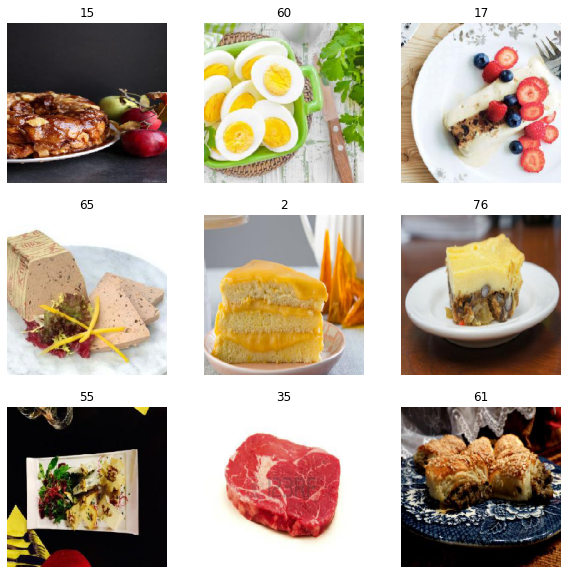

In [22]:
#check prediction
plt.figure(figsize=(10,10))

test_generator.reset()
sample = next(test_generator)

for item in range(9):
    ax = plt.subplot(3, 3, item + 1)
    img = sample[item].astype('uint8')
    label = predicted_labels[item]
    plt.axis('off')
    plt.imshow(img)
    plt.title(label)

## Fine-Tuning

In [36]:
from keras.models import load_model
base_model = load_model('efficientnet_b0_model2.h5')

OSError: SavedModel file does not exist at: efficientnet_b0_model2.h5/{saved_model.pbtxt|saved_model.pb}

In [16]:
base_model.summary()

Model: "functional_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
efficientnetb0 (Functional)  (None, 7, 7, 1280)        4049571   
_________________________________________________________________
global_average_pooling2d (Gl (None, 1280)              0         
_________________________________________________________________
batch_normalization (BatchNo (None, 1280)              5120      
_________________________________________________________________
dropout (Dropout)            (None, 1280)              0         
_________________________________________________________________
dense (Dense)                (None, 80)                102480    
Total params: 4,157,171
Trainable params: 105,040
Non-trainable params: 4,052,131
______________________________________

In [15]:
base_model.load_weights('efficientnet_b0_model2_weights.h5') # prob unnecessary- guessing this is already accomplished when we load the model

In [24]:
len(base_model.layers[1].layers) # this are the efficientnet layers

237

Below adapted from https://keras.io/examples/vision/image_classification_efficientnet_fine_tuning/: essentially we unfreeze the last 20 layers that are non-batchnorm layers

In [21]:
for layer in base_model.layers[1].layers[-20:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

In [23]:
# compile the model again
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"]
)

In [25]:
history = base_model.fit(x=train_generator,
                    validation_data=val_generator,
                    epochs=10,
                    verbose=1,
                    class_weight=class_weights)

Instructions for updating:
The `validate_indices` argument has no effect. Indices are always validated on CPU and never validated on GPU.
Epoch 1/10
766/766 [==============================] - 1081s 1s/step - loss: 1.0324 - accuracy: 0.7024 - val_loss: 1.8804 - val_accuracy: 0.5753
Epoch 2/10
766/766 [==============================] - 1052s 1s/step - loss: 0.8375 - accuracy: 0.7500 - val_loss: 1.8627 - val_accuracy: 0.5822
Epoch 3/10
766/766 [==============================] - 1050s 1s/step - loss: 0.7126 - accuracy: 0.7852 - val_loss: 1.8298 - val_accuracy: 0.5844
Epoch 4/10
766/766 [==============================] - 2371s 3s/step - loss: 0.5990 - accuracy: 0.8200 - val_loss: 1.8477 - val_accuracy: 0.5890
Epoch 5/10
766/766 [==============================] - 1063s 1s/step - loss: 0.5273 - accuracy: 0.8393 - val_loss: 1.8485 - val_accuracy: 0.5905
Epoch 6/10
766/766 [==============================] - 1056s 1s/step - loss: 0.4602 - accuracy: 0.8609 - val_loss: 1.8502 - val_accuracy: 0.595

### Generating the learning curves

Text(0.5, 1.0, 'Training and Validation Accuracy')

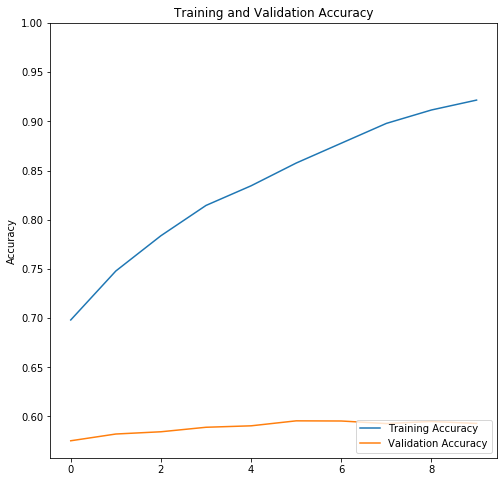

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
# plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

# plt.subplot(2, 1, 2)
# plt.plot(loss, label='Training Loss')
# plt.plot(val_loss, label='Validation Loss')
# plt.legend(loc='upper right')
# plt.ylabel('Cross Entropy')
# plt.ylim([0,1.0])
# plt.title('Training and Validation Loss')
# plt.xlabel('epoch')
# plt.show()

## Classifying the Test Dataset

In [27]:
file_path_testimages, file_path_testlabels, test_labels = bb.get_test_paths()

#Test dataset generator
test_generator=test_datagen.flow_from_dataframe(dataframe=test_labels,
                                            directory=file_path_testimages,
                                            x_col='img_name',
                                            y_col='label',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42,
                                            shuffle=False,
                                            class_mode=None,
                                            interpolation='nearest',
                                            target_size=IMG_SIZE)

Found 7653 validated image filenames.


In [28]:
#load model if required
from tensorflow.keras.models import load_model
model = load_model('efficientnet_b0_model.h5')

OSError: SavedModel file does not exist at: efficientnet_b0_model.h5/{saved_model.pbtxt|saved_model.pb}

In [29]:
test_generator.reset()

#classify our test data
classify = base_model.predict(test_generator,
                         verbose=1)

240/240 [==============================] - 249s 1s/step


In [30]:
predictions = np.argmax(classify, axis=1)
predictions

array([ 6, 56, 35, ..., 72, 41, 23])

In [31]:
#map predicted labels to the labels indices
sorted_labels = (train_generator.class_indices)
sorted_labels = dict((v,k) for k,v in sorted_labels.items())
predicted_labels = [sorted_labels[k] for k in predictions]

In [32]:
#save output
submission_file = pd.DataFrame()
submission_file['img_name'] = test_labels['img_name']
submission_file['label'] = predicted_labels
submission_file.to_csv('test_labels_predictions_standard_unfrozen.csv', index=False)